# Application of Machine Learning for Anomaly Detection in Network Traffic
**Course:** Machine Learning - Final Project
**Dataset:** CICIDS 2017/2018

## Project Overview
This project evaluates both Supervised and Unsupervised machine learning models for detecting network intrusions. We address the **Bias-Variance Tradeoff** by explicitly applying pre-pruning and regularization to our supervised models to prevent overfitting on the lab-generated CICIDS dataset.

### Project Pipeline Stages:
1. Data Preprocessing & Cleaning (Handling missing values, Stratified Sampling)
2. Supervised Learning (Random Forest, XGBoost)
3. Unsupervised Learning (Isolation Forest, Autoencoder)
4. Evaluation & Visualization

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import os
import joblib

# Core ML 
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score,
    average_precision_score
)
import xgboost as xgb

# Deep Learning 
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

---
## Stage 1: Data Loading & Preprocessing
Network traffic data is inherently noisy and massive. This class performs the following critical steps:
* **Sanitization:** Replaces mathematical anomalies (`Infinity`, `NaN`) with column medians.
* **Label Encoding:** Normalizes variations of labels (e.g., "NORMAL TRAFFIC", "BENIGN") into a strict binary format (0 = Normal, 1 = Attack).
* **Stratified Sampling:** Extracts a representative 150,000-row sample to ensure memory efficiency while preserving the real-world attack distribution.
* **Scaling:** Applies `RobustScaler` to normalize the massive ranges in byte/packet counts without being skewed by outliers.

In [2]:
class CICIDSPreprocessor:
    FLOW_FEATURES = [
        'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
        'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
        'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
        'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min',
        'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
        'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
        'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
        'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
        'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
        'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
        'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
        'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
        'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
        'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',
        'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count',
        'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size',
        'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
        'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward',
        'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',
        'Active Mean', 'Active Std', 'Active Max', 'Active Min',
        'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
    ]
    LABEL_COL = 'Label'

    def __init__(self, sample_size: int = 200_000):
        self.sample_size = sample_size
        self.scaler = RobustScaler()       
        self.label_encoder = LabelEncoder()
        self.feature_cols = None

    def load(self, path: str) -> pd.DataFrame:
        import glob
        files = glob.glob(path) if '*' in path else [path]
        dfs = []
        for f in files:
            print(f"  Loading {os.path.basename(f)}...")
            df = pd.read_csv(f, low_memory=False)
            df.columns = df.columns.str.strip()
            dfs.append(df)
        return pd.concat(dfs, ignore_index=True)

    def clean(self, df: pd.DataFrame) -> pd.DataFrame:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        thresh = len(df) * 0.6
        df.dropna(axis=1, thresh=thresh, inplace=True)
        num_cols = df.select_dtypes(include=[np.number]).columns
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())

        for col in num_cols:
            if col != self.LABEL_COL:
                upper = df[col].quantile(0.999)
                df[col] = df[col].clip(upper=upper)
        
        label_variants = ['Label', 'label', ' Label', 'label ', 'Attack Type', 'attack_type', 'Class']
        for v in label_variants:
            if v in df.columns:
                df.rename(columns={v: self.LABEL_COL}, inplace=True)
                break
        return df

    def preprocess(self, df: pd.DataFrame):
        df = self.clean(df)
        available = [c for c in self.FLOW_FEATURES if c in df.columns]
        if len(available) < 10:
            available = [c for c in df.select_dtypes(include=[np.number]).columns if c != self.LABEL_COL]
        self.feature_cols = available
        print(f"  Using {len(self.feature_cols)} features")

        X = df[self.feature_cols].values
        
        y_multi_raw = df[self.LABEL_COL].astype(str).str.strip().str.upper()
        
        print("\n" + "!"*50)
        print("DIAGNOSTIC: Top labels inside file:")
        print(y_multi_raw.value_counts().head(5))
        print("!"*50 + "\n")

        y_multi = self.label_encoder.fit_transform(y_multi_raw)
        normal_labels = ['BENIGN', 'NORMAL', 'NORMAL TRAFFIC', '0', '0.0', 'NAN', 'NONE', 'NULL', 'REGULAR']
        y_binary = (~y_multi_raw.isin(normal_labels)).astype(int).values
        
        if len(X) > self.sample_size:
            idx = np.random.choice(len(X), self.sample_size, replace=False)
            X, y_binary, y_multi = X[idx], y_binary[idx], y_multi[idx]

        X_scaled = self.scaler.fit_transform(X)
        return X_scaled, y_binary, y_multi, self.feature_cols

---
## Stage 2: Supervised Learning (Mitigating Overfitting)
To prevent the models from memorizing the specific packet sizes of lab-generated attacks, we applied strict **Regularization and Pre-Pruning**:
* **Random Forest:** Restricted `max_depth` to 5 and increased `min_samples_split` to force generalization.
* **XGBoost:** Added L1/L2 penalties (`reg_alpha`, `reg_lambda`) to penalize overly complex decision boundaries.

In [3]:
class SupervisedDetector:
    def __init__(self):
        self.rf = RandomForestClassifier(
            n_estimators=100,          
            max_depth=5,               # STRICT PRUNING
            min_samples_split=20,      
            min_samples_leaf=10,       
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        )
        self.xgb = xgb.XGBClassifier(
            n_estimators=100,          
            max_depth=3,               # STRICT PRUNING
            learning_rate=0.1,         
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,            # L2 Regularization 
            reg_alpha=0.5,             # L1 Regularization 
            scale_pos_weight=1,
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1,
            random_state=42
        )
        self.results = {}

    def train_evaluate(self, X_train, X_test, y_train, y_test, feature_names):
        models = {'Random Forest': self.rf, 'XGBoost': self.xgb}
        for name, model in models.items():
            print(f"\n  Training {name}...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            self.results[name] = {
                'accuracy':  accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'recall':    recall_score(y_test, y_pred, zero_division=0),
                'f1':        f1_score(y_test, y_pred, zero_division=0),
                'roc_auc':   roc_auc_score(y_test, y_prob),
                'avg_precision': average_precision_score(y_test, y_prob),
                'confusion_matrix': confusion_matrix(y_test, y_pred),
                'y_pred': y_pred,
                'y_prob': y_prob,
                'feature_importance': (
                    pd.Series(model.feature_importances_, index=feature_names)
                    .sort_values(ascending=False).head(20)
                ),
                'report': classification_report(y_test, y_pred, target_names=['BENIGN', 'ATTACK'])
            }
            print(f"    F1={self.results[name]['f1']:.4f}  ROC-AUC={self.results[name]['roc_auc']:.4f}  Recall={self.results[name]['recall']:.4f}")
        return self.results

---
## Stage 3: Unsupervised Learning
To simulate a real-world "Zero-Day" scenario where the attack signatures are unknown, we test **Isolation Forest** and an **Autoencoder** Neural Network. These models underfit on this dataset, highlighting the extreme difficulty of separating malicious traffic from noisy normal traffic without labeled guidance.

In [4]:
class UnsupervisedDetector:
    def __init__(self):
        self.iso_forest = IsolationForest(
            n_estimators=200, contamination=0.1, max_features=1.0,
            bootstrap=False, n_jobs=-1, random_state=42
        )
        self.autoencoder = None
        self.ae_threshold = None
        self.results = {}

    def _build_autoencoder(self, input_dim: int) -> Model:
        enc_dim = max(8, input_dim // 4)
        bottleneck = max(4, input_dim // 16)
        inputs = layers.Input(shape=(input_dim,))
        
        x = layers.Dense(enc_dim, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(enc_dim // 2, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        encoded = layers.Dense(bottleneck, activation='relu', name='bottleneck')(x)
        
        x = layers.Dense(enc_dim // 2, activation='relu')(encoded)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(enc_dim, activation='relu')(x)
        decoded = layers.Dense(input_dim, activation='linear')(x)

        model = Model(inputs, decoded, name='Autoencoder')
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
        return model

    def train_iso_forest(self, X_train, X_test, y_test):
        print("\n  Training Isolation Forest...")
        self.iso_forest.fit(X_train)
        scores = -self.iso_forest.score_samples(X_test)
        preds = (self.iso_forest.predict(X_test) == -1).astype(int)
        self.results['Isolation Forest'] = self._metrics(y_test, preds, scores, 'Isolation Forest')
        return self.results['Isolation Forest']

    def train_autoencoder(self, X_train, X_test, y_test):
        print("\n  Training Autoencoder...")
        input_dim = X_train.shape[1]
        self.autoencoder = self._build_autoencoder(input_dim)
        cb = [callbacks.EarlyStopping(patience=5, restore_best_weights=True), callbacks.ReduceLROnPlateau(patience=3, factor=0.5)]
        
        history = self.autoencoder.fit(
            X_train, X_train, epochs=50, batch_size=512,
            validation_split=0.1, callbacks=cb, verbose=0
        )
        recon = self.autoencoder.predict(X_test, verbose=0)
        mse_scores = np.mean(np.square(X_test - recon), axis=1)

        train_recon = self.autoencoder.predict(X_train, verbose=0)
        train_mse = np.mean(np.square(X_train - train_recon), axis=1)
        self.ae_threshold = np.percentile(train_mse, 95)

        preds = (mse_scores > self.ae_threshold).astype(int)
        self.results['Autoencoder'] = self._metrics(y_test, preds, mse_scores, 'Autoencoder')
        self.results['Autoencoder']['history'] = history.history
        self.results['Autoencoder']['threshold'] = self.ae_threshold
        return self.results['Autoencoder']

    def _metrics(self, y_true, y_pred, scores, name):
        m = {
            'accuracy':  accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall':    recall_score(y_true, y_pred, zero_division=0),
            'f1':        f1_score(y_true, y_pred, zero_division=0),
            'roc_auc':   roc_auc_score(y_true, scores),
            'avg_precision': average_precision_score(y_true, scores),
            'confusion_matrix': confusion_matrix(y_true, y_pred),
            'y_pred': y_pred, 'y_prob': scores,
        }
        print(f"    F1={m['f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}  Recall={m['recall']:.4f}")
        return m

---
## Stage 4: Visualization Dashboard

In [5]:
class ResultVisualizer:
    PALETTE = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77']
    BG, FG, GRID = '#0d1117', '#e6edf3', '#21262d'

    def _style(self):
        plt.rcParams.update({
            'figure.facecolor': self.BG, 'axes.facecolor': self.BG,
            'axes.edgecolor': self.GRID, 'axes.labelcolor': self.FG,
            'xtick.color': self.FG, 'ytick.color': self.FG,
            'text.color': self.FG, 'grid.color': self.GRID,
            'grid.alpha': 0.4, 'font.family': 'monospace'
        })

    def comparison_dashboard(self, sup_results, unsup_results, save_path):
        self._style()
        all_results = {**sup_results, **unsup_results}
        models = list(all_results.keys())
        colors = dict(zip(models, self.PALETTE))

        fig = plt.figure(figsize=(20, 14), facecolor=self.BG)
        fig.suptitle('Network Anomaly Detection — Model Comparison\nCICIDS 2017/2018', fontsize=16, color=self.FG, fontweight='bold', y=0.98)
        gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

        # Bar chart
        ax1 = fig.add_subplot(gs[0, :2])
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
        x, w = np.arange(len(metrics)), 0.18
        for i, (name, res) in enumerate(all_results.items()):
            vals = [res[m] for m in metrics]
            bars = ax1.bar(x + i * w, vals, w, label=name, color=colors[name], alpha=0.85, edgecolor='none')
            for bar, val in zip(bars, vals):
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.2f}', ha='center', va='bottom', fontsize=6.5, color=self.FG)
        ax1.set_xticks(x + w * 1.5)
        ax1.set_xticklabels([m.replace('_', '\n') for m in metrics], fontsize=8)
        ax1.set_ylim(0, 1.12)
        ax1.set_title('Performance Metrics', color=self.FG, fontsize=11)
        ax1.legend(fontsize=8, framealpha=0.2)
        ax1.grid(axis='y', alpha=0.3)

        # Radar chart
        ax2 = fig.add_subplot(gs[0, 2:], polar=True)
        cats = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
        angles = np.linspace(0, 2 * np.pi, len(cats), endpoint=False).tolist()
        angles += angles[:1]
        for name, res in all_results.items():
            vals = [res[m] for m in metrics] + [res[metrics[0]]]
            ax2.plot(angles, vals, 'o-', color=colors[name], linewidth=2, label=name)
            ax2.fill(angles, vals, color=colors[name], alpha=0.1)
        ax2.set_xticks(angles[:-1])
        ax2.set_xticklabels(cats, size=8, color=self.FG)
        ax2.set_ylim(0, 1)
        ax2.set_title('Radar Overview', color=self.FG, fontsize=11, pad=15)
        ax2.tick_params(colors=self.FG)
        ax2.grid(color=self.GRID, alpha=0.5)
        ax2.set_facecolor(self.BG)
        ax2.spines['polar'].set_color(self.GRID)

        # Confusion matrices
        cmap = LinearSegmentedColormap.from_list('cyber', ['#0d1117', '#00d4ff'])
        for i, (name, res) in enumerate(all_results.items()):
            ax = fig.add_subplot(gs[1, i])
            cm = res['confusion_matrix']
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap, ax=ax, linewidths=0.5, linecolor=self.GRID, cbar=False, annot_kws={'size': 9})
            ax.set_title(f'{name}\nConfusion Matrix', color=self.FG, fontsize=9)
            ax.set_xticklabels(['BENIGN', 'ATTACK'], fontsize=7)
            ax.set_yticklabels(['BENIGN', 'ATTACK'], fontsize=7, rotation=0)

        # Feature importance (RF)
        ax5 = fig.add_subplot(gs[2, :2])
        if 'Random Forest' in sup_results:
            fi = sup_results['Random Forest']['feature_importance'].head(15)
            ax5.barh(fi.index[::-1], fi.values[::-1], color=self.PALETTE[0], alpha=0.8)
            ax5.set_title('Top 15 Features — Random Forest', color=self.FG, fontsize=10)
            ax5.grid(axis='x', alpha=0.3)
            ax5.tick_params(labelsize=7)

        # AE training loss
        ax6 = fig.add_subplot(gs[2, 2:])
        if 'Autoencoder' in unsup_results and 'history' in unsup_results['Autoencoder']:
            h = unsup_results['Autoencoder']['history']
            ax6.plot(h['loss'], color=self.PALETTE[2], label='Train Loss', linewidth=2)
            ax6.plot(h['val_loss'], color=self.PALETTE[1], label='Val Loss', linewidth=2, linestyle='--')
            ax6.set_title('Autoencoder Training Loss', color=self.FG, fontsize=10)
            ax6.legend(fontsize=8, framealpha=0.2)
            ax6.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

---
## Stage 5: Execution Pipeline
Running the complete pipeline on the loaded CSV files.

  CICIDS Network Anomaly Detection Pipeline

[1/4] Loading & preprocessing data...
  Loading cicids2017_cleaned.csv...
  Using 51 features

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DIAGNOSTIC: Top labels inside file:
Label
NORMAL TRAFFIC    2095057
DOS                193745
DDOS               128014
PORT SCANNING       90694
BRUTE FORCE          9150
Name: count, dtype: int64
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


[2/4] Supervised models (Random Forest + XGBoost)...

  Training Random Forest...
    F1=0.9560  ROC-AUC=0.9969  Recall=0.9624

  Training XGBoost...
    F1=0.9821  ROC-AUC=0.9994  Recall=0.9747

[3/4] Unsupervised models (Isolation Forest + Autoencoder)...

  Training Isolation Forest...
    F1=0.3461  ROC-AUC=0.7927  Recall=0.2752

  Training Autoencoder...
    F1=0.3991  ROC-AUC=0.6945  Recall=0.2590

[4/4] Generating dashboard...


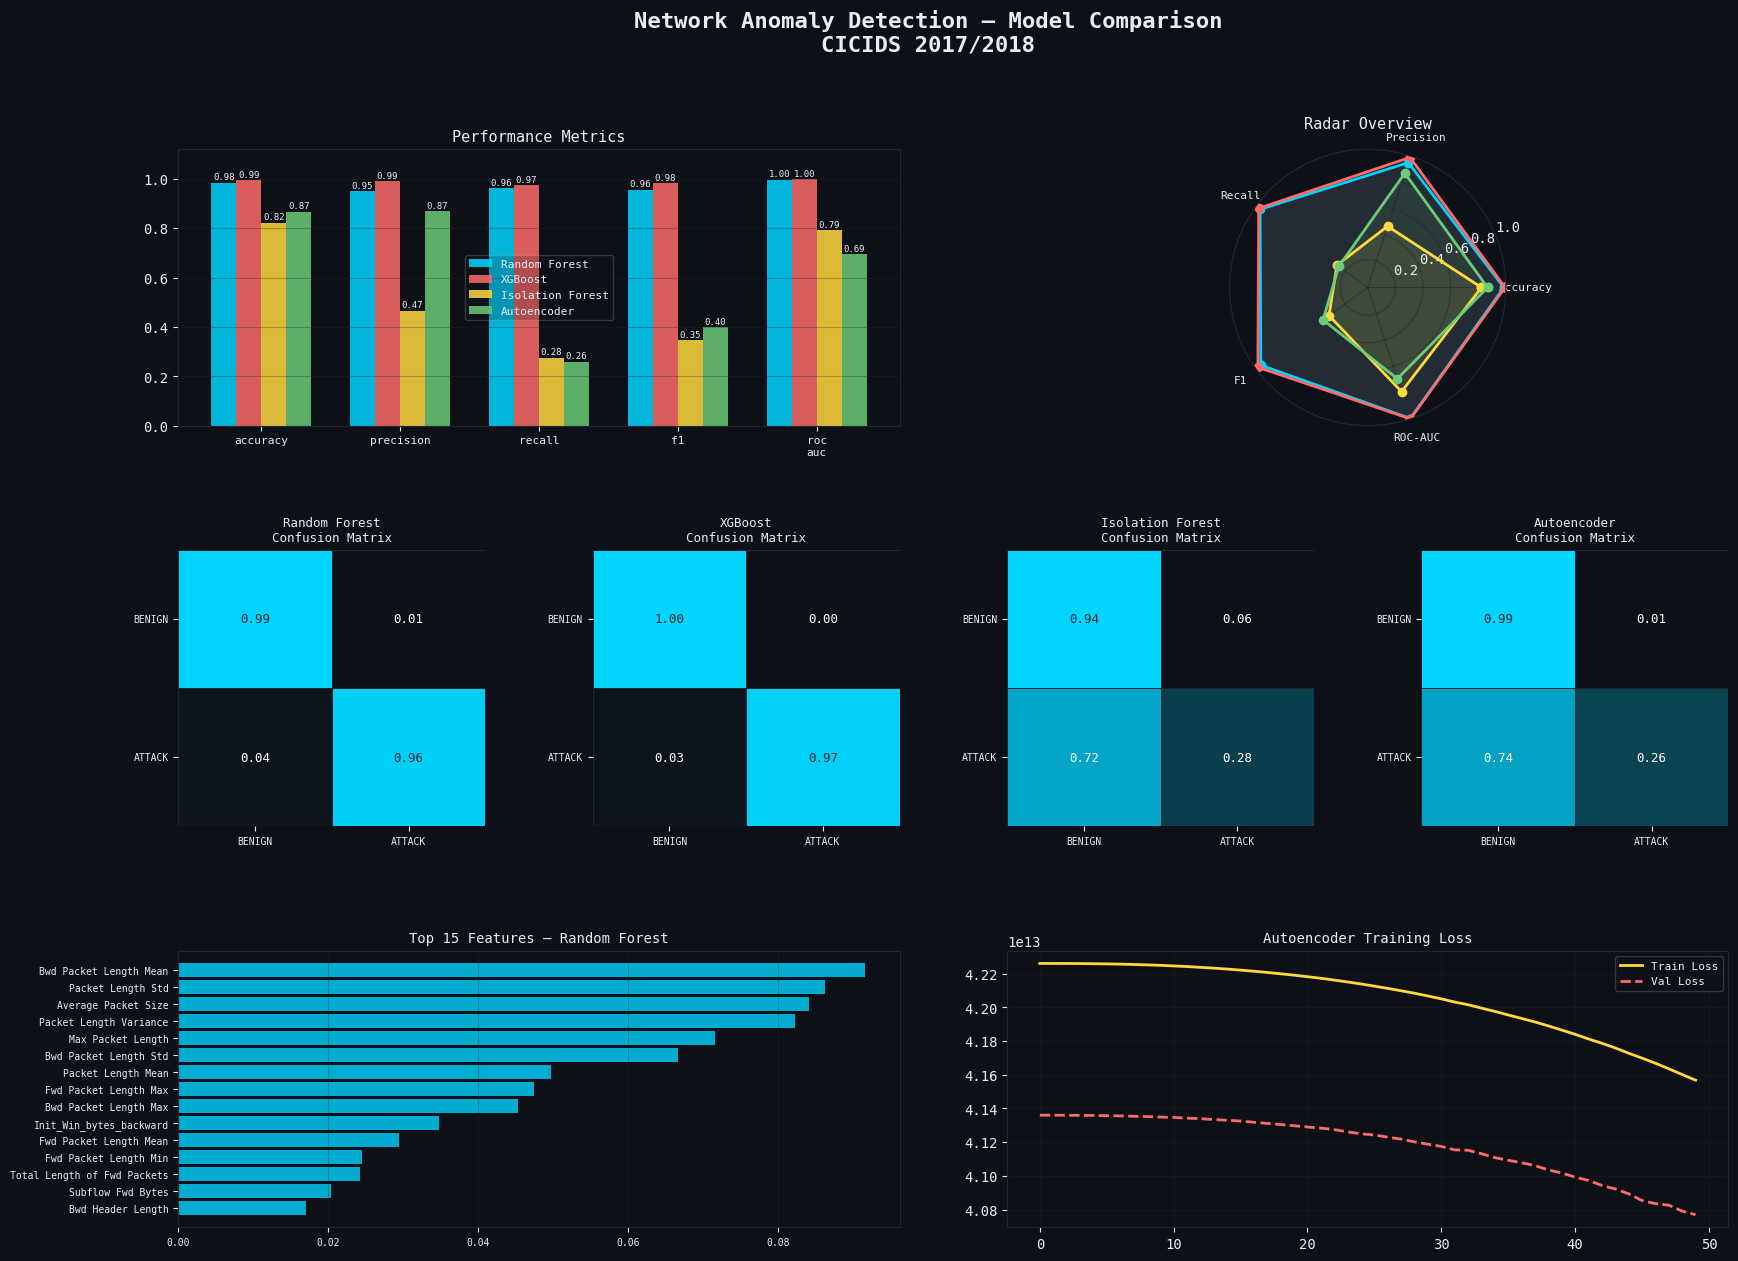


  RESULTS SUMMARY
Model                   Acc   Prec    Rec     F1    AUC
-------------------------------------------------------
Random Forest        0.9849 0.9497 0.9624 0.9560 0.9969
XGBoost              0.9940 0.9897 0.9747 0.9821 0.9994
Isolation Forest     0.8230 0.4660 0.2752 0.3461 0.7927
Autoencoder          0.8673 0.8697 0.2590 0.3991 0.6945


In [6]:
# Execution Block
data_path = 'data/*.csv'
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

print("=" * 60)
print("  CICIDS Network Anomaly Detection Pipeline")
print("=" * 60)

# 1. Preprocess
print("\n[1/4] Loading & preprocessing data...")
prep = CICIDSPreprocessor(sample_size=150_000)
df_raw = prep.load(data_path)
X, y_binary, y_multi, feature_names = prep.preprocess(df_raw)

# Train/test split — stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 2. Supervised
print("\n[2/4] Supervised models (Random Forest + XGBoost)...")
sup = SupervisedDetector()
sup_results = sup.train_evaluate(X_train, X_test, y_train, y_test, feature_names)

# 3. Unsupervised
print("\n[3/4] Unsupervised models (Isolation Forest + Autoencoder)...")
unsup = UnsupervisedDetector()
unsup.train_iso_forest(X_train, X_test, y_test)
unsup.train_autoencoder(X_train, X_test, y_test)
unsup_results = unsup.results

# 4. Visualize
print("\n[4/4] Generating dashboard...")
viz = ResultVisualizer()
viz.comparison_dashboard(sup_results, unsup_results, os.path.join(output_dir, 'comparison_dashboard.png'))

# Summary
print("\n" + "=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
all_res = {**sup_results, **unsup_results}
header = f"{'Model':<20} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}"
print(header)
print("-" * len(header))
for name, r in all_res.items():
    print(f"{name:<20} {r['accuracy']:>6.4f} {r['precision']:>6.4f} "
          f"{r['recall']:>6.4f} {r['f1']:>6.4f} {r['roc_auc']:>6.4f}")